<a href="https://colab.research.google.com/github/UsmanArif169/Scikit-learn-Tutorial/blob/main/Scikilt_learn_Labelencoder_and_Ordinarencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/CAR DETAILS FROM CAR DEKHO.csv')
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [ ]:
df = pd.read_csv('/content/CAR DETAILS FROM CAR DEKHO.csv', usecols = ['seller_type','transmission','fuel','owner'])
df.head()

,fuel,seller_type,transmission,owner
0,Petrol,Individual,Manual,First Owner
1,Petrol,Individual,Manual,First Owner
2,Diesel,Individual,Manual,First Owner
3,Petrol,Individual,Manual,First Owner
4,Diesel,Individual,Manual,Second Owner


In [ ]:
df.shape

(4340, 4)

In [ ]:
df.describe()

,fuel,seller_type,transmission,owner
count,4340,4340,4340,4340
unique,5,3,2,5
top,Diesel,Individual,Manual,First Owner
freq,2153,3244,3892,2832


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   fuel          4340 non-null   object
 1   seller_type   4340 non-null   object
 2   transmission  4340 non-null   object
 3   owner         4340 non-null   object
dtypes: object(4)
memory usage: 135.8+ KB


In [ ]:
df.isnull().sum()

,0
fuel,0
seller_type,0
transmission,0
owner,0


<Axes: xlabel='fuel', ylabel='count'>

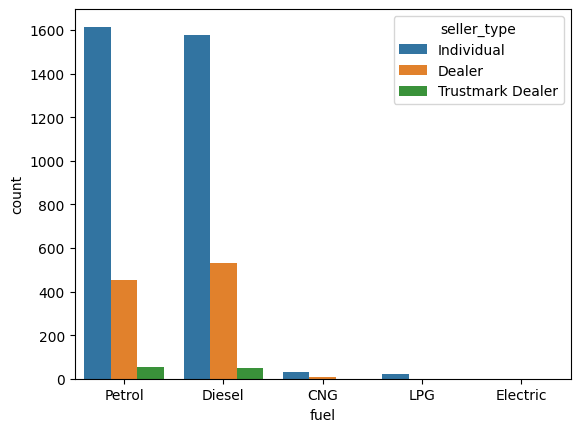

In [ ]:
sns.countplot(x='fuel', hue='seller_type', data=df)

In [ ]:
df['fuel'].value_counts()

,count
fuel,
Diesel,2153
Petrol,2123
CNG,40
LPG,23
Electric,1


In [ ]:
df['seller_type'].value_counts()

,count
seller_type,
Individual,3244
Dealer,994
Trustmark Dealer,102


In [ ]:
df['transmission'].value_counts()

,count
transmission,
Manual,3892
Automatic,448


# **Using Python to convert categorical to numerical data**

In [ ]:
#df['transmission'] = df['transmission'].map({'Manual':0, 'Automatic':1})
#df['fuel'] = df['fuel'].map({'Petrol':0, 'Diesel':1})
#df['seller_type'] = df['seller_type'].map({'Individual':0, 'Dealer':1})
#df['owner'] = df['owner'].map({'First':0, 'Second':1, 'Third':2, 'Fourth':3})

In [ ]:
df.head()

,fuel,seller_type,transmission,owner
0,Petrol,Individual,Manual,First Owner
1,Petrol,Individual,Manual,First Owner
2,Diesel,Individual,Manual,First Owner
3,Petrol,Individual,Manual,First Owner
4,Diesel,Individual,Manual,Second Owner


# **Using Scikit-learn to convert categorical to numerical data**

In [ ]:
X = df.drop(columns = 'fuel', axis = 1)
y = df['fuel']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
X_train

,seller_type,transmission,owner
227,Individual,Manual,First Owner
964,Individual,Manual,First Owner
2045,Individual,Manual,Second Owner
1025,Individual,Manual,First Owner
4242,Dealer,Manual,First Owner
...,...,...,...
3444,Individual,Manual,First Owner
466,Individual,Manual,First Owner
3092,Dealer,Manual,First Owner
3772,Individual,Manual,First Owner


# **Apply Label Encoder**

In [ ]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
le = LabelEncoder()
oe = OrdinalEncoder()

In [ ]:
y_train_trf=le.fit_transform(y_train)
y_test_trf=le.transform(y_test)

In [ ]:
y_train_trf

array([1, 1, 4, ..., 1, 1, 4])

In [ ]:
y_train_trf=pd.DataFrame(data = y_train_trf, columns = ['fuel_encoded'])
y_test_trf=pd.DataFrame(data = y_test_trf, columns = ['fuel_encoded'])

In [ ]:
y_train_trf

,fuel_encoded
0,1
1,1
2,4
3,1
4,1
...,...
3467,1
3468,1
3469,1
3470,1


In [ ]:
X_train_trf = oe.fit_transform(X_train)
X_test_trf = oe.transform(X_test)

In [ ]:
X_train_trf

array([[1., 1., 0.],
       [1., 1., 0.],
       [1., 1., 2.],
       ...,
       [0., 1., 0.],
       [1., 1., 0.],
       [1., 1., 0.]])

In [ ]:
X_train_trf = pd.DataFrame(data = X_train_trf, columns = X_train.columns)
X_test_trf = pd.DataFrame(data = X_test_trf, columns = X_test.columns)

In [ ]:
X_train_trf

,seller_type,transmission,owner
0,1.0,1.0,0.0
1,1.0,1.0,0.0
2,1.0,1.0,2.0
3,1.0,1.0,0.0
4,0.0,1.0,0.0
...,...,...,...
3467,1.0,1.0,0.0
3468,1.0,1.0,0.0
3469,0.0,1.0,0.0
3470,1.0,1.0,0.0
